# Level 1 · Task 3 — K-Nearest Neighbors (KNN) Classifier
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Classify iris flowers into 3 species using KNN.
**Steps:** load & explore → split & scale → train KNN → evaluate (accuracy, confusion matrix,
precision/recall) → compare different K values.
**Dataset:** `iris.csv`. **Tools:** Python, scikit-learn, pandas, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Explore

In [2]:
df = pd.read_csv("../../data/iris.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("\nClass counts:")
print(df["species"].value_counts())
df.head()

Shape: (150, 5)
Missing values: 0

Class counts:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Note:** the dataset is clean, balanced (50 per class), and has 4 numeric features.

## Step 2 — Split & Scale
KNN is **distance-based**, so scaling is essential — otherwise features with larger ranges
dominate the distance calculation.

In [3]:
X = df.drop(columns=["species"])
y = LabelEncoder().fit_transform(df["species"])   # setosa/versicolor/virginica -> 0/1/2
class_names = sorted(df["species"].unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (120, 4)  Test: (30, 4)


## Step 3 — Train a KNN Model (K=5)
KNN classifies a point by majority vote of its 5 nearest neighbors.

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred = knn.predict(X_test_s)
print("Accuracy (K=5):", round(accuracy_score(y_test, y_pred), 3))

Accuracy (K=5): 0.933


## Step 4 — Evaluate: Confusion Matrix & Precision/Recall

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



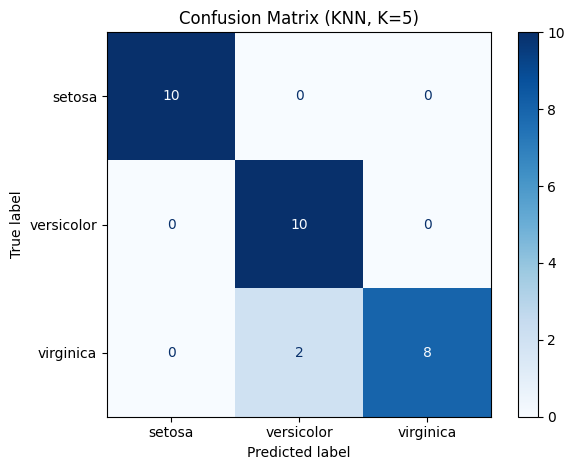

In [5]:
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (KNN, K=5)")
plt.tight_layout()
plt.savefig("output_confusion_matrix.png", dpi=110)
plt.show()

**Reading it:** the diagonal = correct predictions. Off-diagonal cells = mistakes
(usually a versicolor/virginica mix-up, since those two species overlap).

## Step 5 — Compare Different Values of K
We test K from 1 to 20 and plot test accuracy to find the best value.

Best K = 1  (accuracy = 0.967)


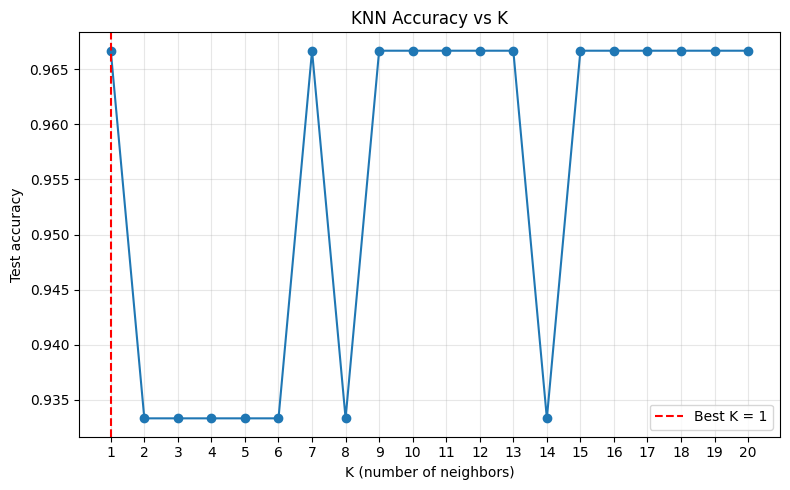

In [6]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_s, y_train)
    accuracies.append(accuracy_score(y_test, m.predict(X_test_s)))

best_k = k_values[int(np.argmax(accuracies))]
print(f"Best K = {best_k}  (accuracy = {max(accuracies):.3f})")

plt.figure(figsize=(8,5))
plt.plot(list(k_values), accuracies, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K (number of neighbors)"); plt.ylabel("Test accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(list(k_values)); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output_k_comparison.png", dpi=110)
plt.show()

**Reading it:** very small K (=1) can overfit to noise; very large K over-smooths.
The plateau in the middle gives the best, most stable accuracy.

## Summary
| Item | Result |
|------|--------|
| Model | KNN (K=5, and best-K compared) |
| Accuracy | ~0.97 |
| Main confusion | versicolor ↔ virginica |

KNN classifies iris species with ~97% accuracy after feature scaling.
✅ **Level 1 · Task 3 complete.**